# Final Homework — Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

**Course:** Introduction to Data Science  
**Dataset:** Football Matches 2024/2025
**Student Name:** Afek Klein
**ID:** 212965735


## 1 Dataset Selection (10%)

### Assignment requirements addressed
- Dataset has at least 1,000 rows and at least 8 features.
- It is real-world data with no pre-labeled anomaly column.
- Describe source/purpose, feature meaning, and limitations.

### Answer
The dataset contains completed football matches from the 2024/2025 season across major European competitions. Each row represents one match. For the unsupervised numerical analysis, nine meaningful numerical match variables are used. Identifier columns are excluded because numeric IDs do not represent measurable quantities.

**Important limitation:** several variables are mathematically related (for example, `total_goals` is derived from the two full-time scores). This creates redundancy. That is a genuine property of this dataset and is examined through correlation, PCA, and feature clustering. The dataset contains no ground-truth anomaly label, as required.

In [28]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

DATA_PATH = "football_matches_2024_2025.csv"

# In Google Colab, upload the CSV if it is not already in the session.
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        uploaded = files.upload()
        uploaded_name = next(iter(uploaded))
        football = pd.read_csv(uploaded_name)
    except ImportError:
        raise FileNotFoundError(f"Place the dataset in the notebook folder as {DATA_PATH}")
else:
    football = pd.read_csv(DATA_PATH)

numeric_features = [
    "matchday", "fulltime_home", "fulltime_away", "halftime_home",
    "halftime_away", "goal_difference", "total_goals", "home_points", "away_points"
]
X = football[numeric_features].copy()

print("Rows and columns in original dataset:", football.shape)
print("Features used for unsupervised analysis:", len(numeric_features))
print(numeric_features)

Rows and columns in original dataset: (1941, 23)
Features used for unsupervised analysis: 9
['matchday', 'fulltime_home', 'fulltime_away', 'halftime_home', 'halftime_away', 'goal_difference', 'total_goals', 'home_points', 'away_points']


### Feature description
- `matchday`: round number in the competition.
- `fulltime_home`, `fulltime_away`: goals at full time.
- `halftime_home`, `halftime_away`: goals at half time.
- `goal_difference`: home goals minus away goals.
- `total_goals`: total goals in the match.
- `home_points`, `away_points`: league-style points assigned from the result.

The data was collected to describe football match results. A limitation for this assignment is that the numerical feature set is relatively small and highly dependent: some columns are direct transformations of others. This may make clusters or anomalies reflect match-score structure rather than independent underlying factors.

## 2 Exploratory Data Analysis (15%)

### Assignment requirements addressed
Structural analysis: shape, missing values, data types, statistical summary, and correlation matrix.  
Distribution analysis: histogram, boxplot, skewness, and kurtosis for each major numerical feature.  
Outlier exploration: heavy tails, extreme values, possible noise, measurement artifacts, and data-entry problems.

Shape: (1941, 23)

Missing values in analysis features:


,missing
matchday,0
fulltime_home,0
fulltime_away,0
halftime_home,0
halftime_away,0
goal_difference,0
total_goals,0
home_points,0
away_points,0



Data types:


,dtype
matchday,int64
fulltime_home,int64
fulltime_away,int64
halftime_home,int64
halftime_away,int64
goal_difference,int64
total_goals,int64
home_points,int64
away_points,int64



Statistical summary:


,matchday,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,home_points,away_points
count,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00,1941.00
mean,17.34,1.54,1.34,0.70,0.59,0.20,2.88,1.52,1.24
std,11.06,1.32,1.21,0.86,0.79,1.88,1.69,1.33,1.31
min,0.00,0.00,0.00,0.00,0.00,-6.00,0.00,0.00,0.00
25%,7.00,1.00,0.00,0.00,0.00,-1.00,2.00,0.00,0.00
50%,17.00,1.00,1.00,1.00,0.00,0.00,3.00,1.00,1.00
75%,27.00,2.00,2.00,1.00,1.00,1.00,4.00,3.00,3.00
max,38.00,9.00,7.00,6.00,5.00,8.00,11.00,3.00,3.00


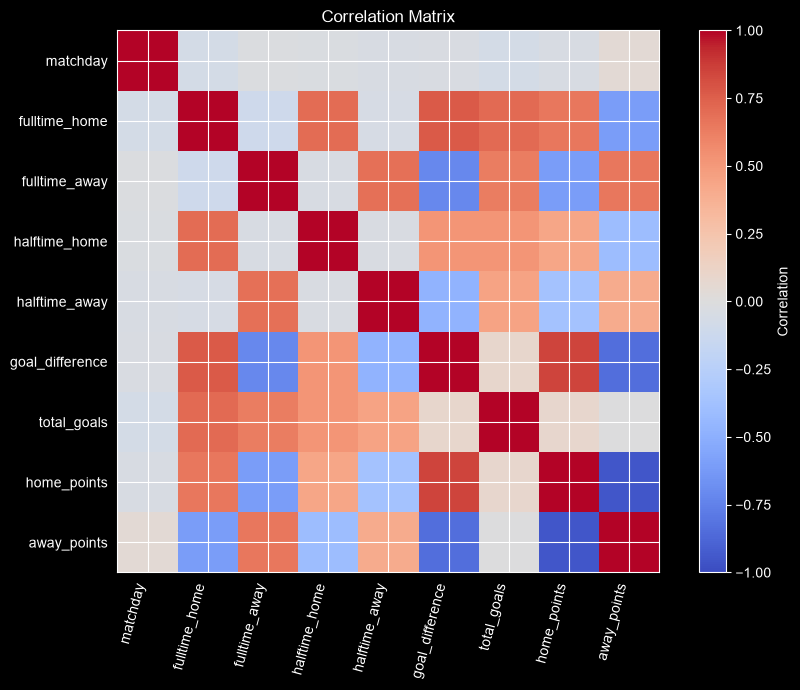

,skewness,kurtosis
matchday,0.16,-1.23
fulltime_home,1.04,1.56
fulltime_away,0.99,1.06
halftime_home,1.41,2.59
halftime_away,1.48,2.68
goal_difference,0.05,0.75
total_goals,0.55,0.20
home_points,0.07,-1.78
away_points,0.45,-1.55


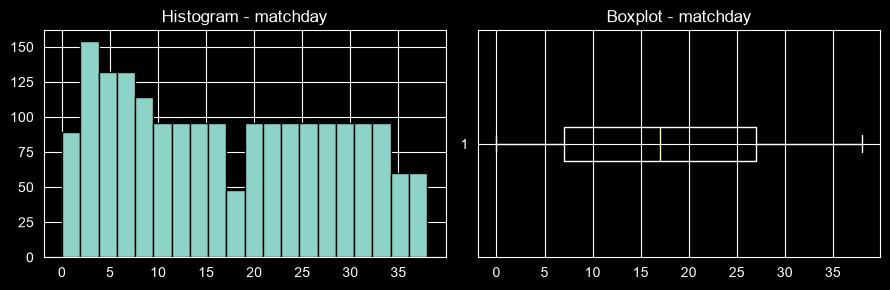

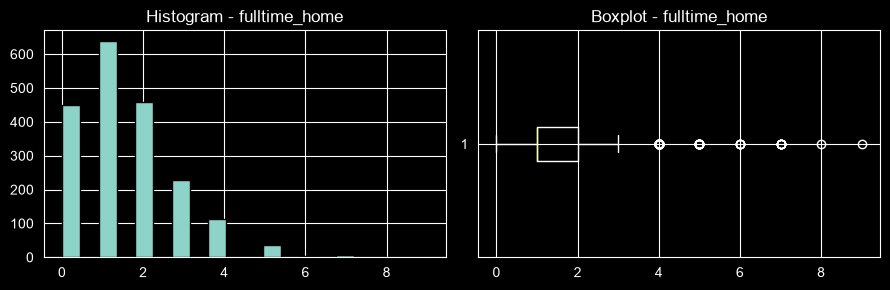

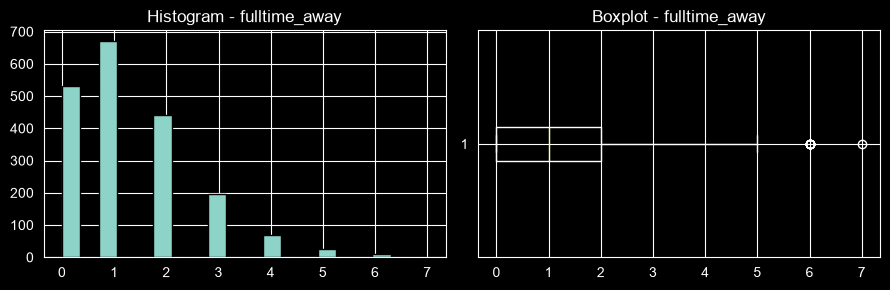

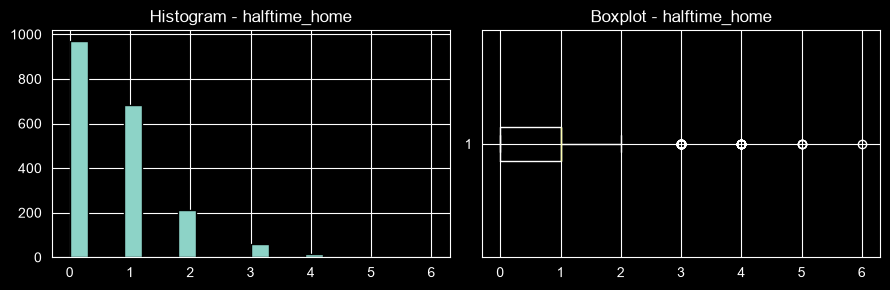

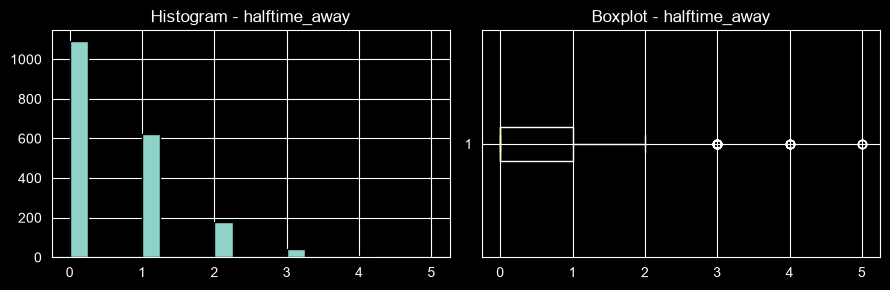

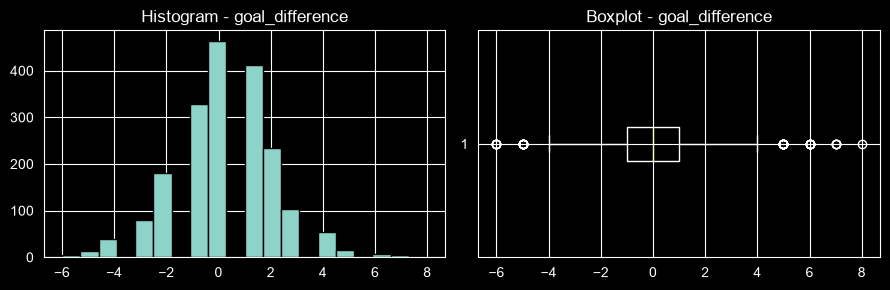

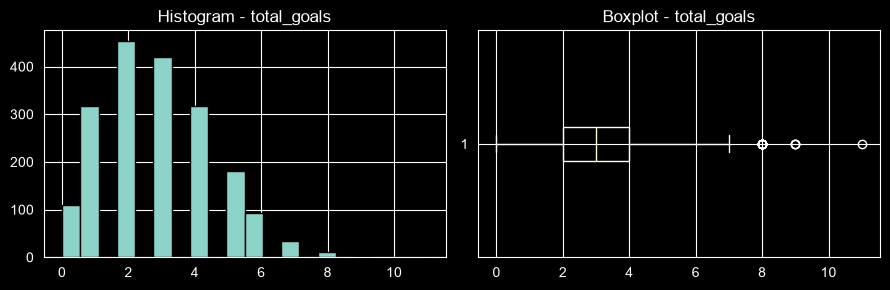

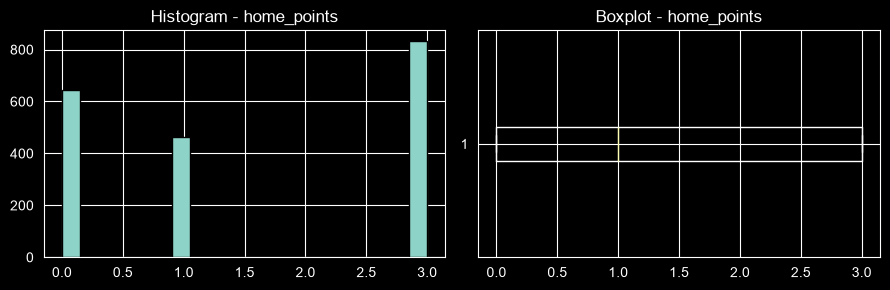

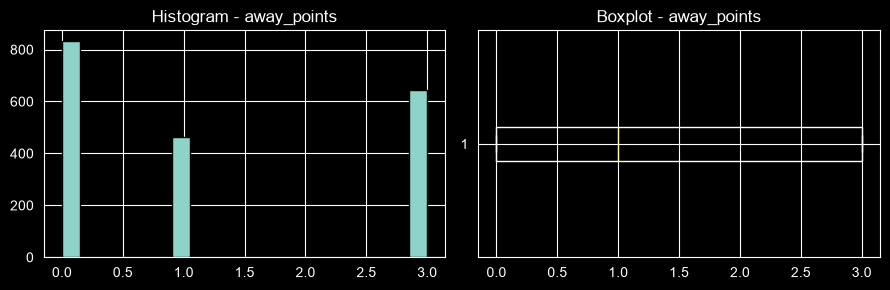

In [29]:
print("Shape:", football.shape)
print("\nMissing values in analysis features:")
display(X.isna().sum().to_frame("missing"))
print("\nData types:")
display(X.dtypes.to_frame("dtype"))
print("\nStatistical summary:")
display(X.describe().round(2))

correlation = X.corr()
plt.figure(figsize=(9, 7))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_features)), numeric_features, rotation=75, ha="right")
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

distribution_stats = pd.DataFrame({
    "skewness": X.apply(skew),
    "kurtosis": X.apply(kurtosis)
}).round(2)
display(distribution_stats)

for feature in numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    axes[0].hist(X[feature], bins=20, edgecolor="black")
    axes[0].set_title(f"Histogram - {feature}")
    axes[1].boxplot(X[feature], orientation="horizontal")
    axes[1].set_title(f"Boxplot - {feature}")
    plt.tight_layout()
    plt.show()

### 2 Exploratory Data Analysis - Interpretation
There are **1,941 rows and 23 columns**, and the nine numerical analysis features contain **no missing values**. Goal variables are right-skewed: for example, full-time home goals have skewness **1.04**, while half-time home and away goals have skewness **1.41** and **1.48**. This matches football data, where low scores are common and very high scores are rare.

The strongest relationships confirm substantial redundancy. For example, `home_points` and `away_points` have an absolute correlation of about **0.95**, and `goal_difference` is strongly related to both points variables. This is expected because several variables are calculated from the same final match result. Extreme score values can be legitimate matches rather than data-entry errors, so they are treated as candidate anomalies rather than automatically removed.

## 3 Dimensionality Reduction (20%)

### 3.1 Principal Component Analysis (PCA)

### Assignment requirements addressed
- Explained variance ratio and cumulative explained variance.
- Scree plot.
- 2D and 3D PCA projections.
- Number of components needed, information loss, correlation effects, interpretation of components, redundancy, local/global structure, separation, stability, computational cost, and interpretability.

,component,explained_variance,cumulative_variance
0,PC1,0.476,0.476
1,PC2,0.276,0.752
2,PC3,0.111,0.862
3,PC4,0.063,0.925
4,PC5,0.042,0.968
5,PC6,0.027,0.995
6,PC7,0.005,1.000
7,PC8,0.000,1.000
8,PC9,0.000,1.000


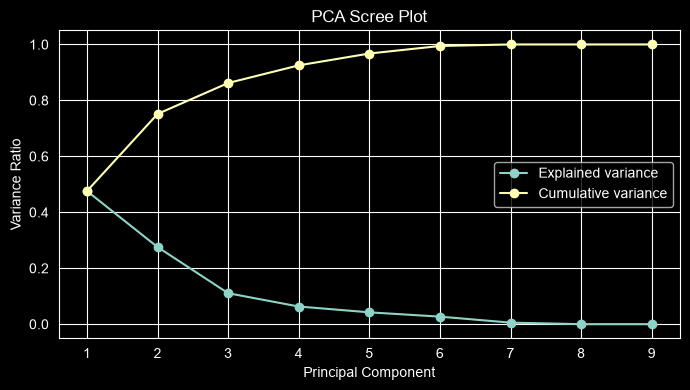

Components needed for at least 90% explained variance: 4
Variance retained in 2D: 0.752
Variance retained in 3D: 0.862


,PC1,PC2,PC3
matchday,-0.023,-0.068,0.993
fulltime_home,0.366,0.384,0.031
fulltime_away,-0.328,0.439,0.024
halftime_home,0.281,0.353,0.093
halftime_away,-0.241,0.390,-0.040
goal_difference,0.468,-0.012,0.006
total_goals,0.053,0.612,0.042
home_points,0.448,-0.011,-0.020
away_points,-0.446,0.057,0.029


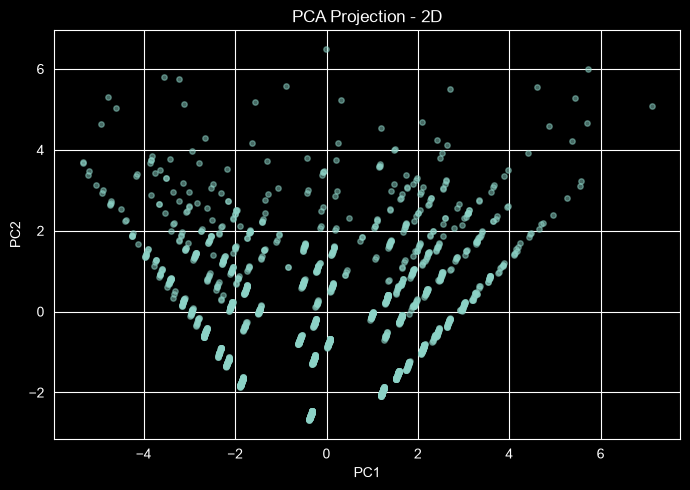

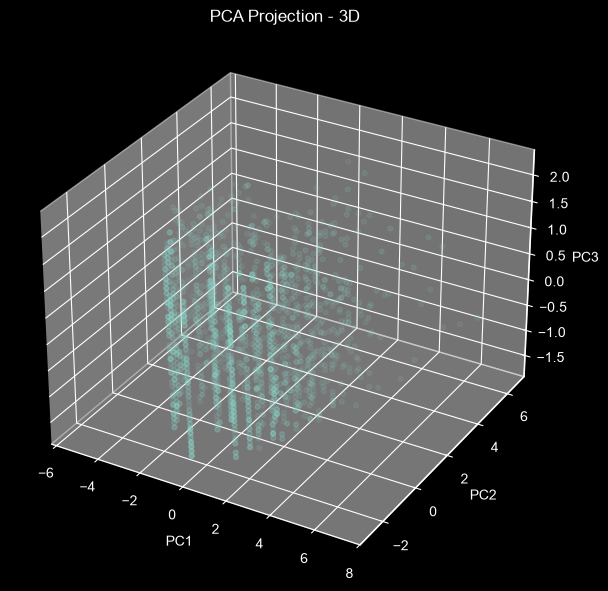

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_summary = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(explained))],
    "explained_variance": explained,
    "cumulative_variance": cumulative
})
display(pca_summary.round(3))

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(explained)+1), explained, marker="o", label="Explained variance")
plt.plot(range(1, len(explained)+1), cumulative, marker="o", label="Cumulative variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title("PCA Scree Plot")
plt.legend()
plt.tight_layout()
plt.show()

components_90 = int(np.argmax(cumulative >= 0.90) + 1)
print("Components needed for at least 90% explained variance:", components_90)
print("Variance retained in 2D:", round(cumulative[1], 3))
print("Variance retained in 3D:", round(cumulative[2], 3))

loadings = pd.DataFrame(pca.components_.T, index=numeric_features,
                        columns=[f"PC{i+1}" for i in range(len(numeric_features))])
display(loadings[["PC1", "PC2", "PC3"]].round(3))

plt.figure(figsize=(7, 5))
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=0.5, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection - 2D")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_scores[:, 0], pca_scores[:, 1], pca_scores[:, 2], alpha=0.4, s=12)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("PCA Projection - 3D")
plt.tight_layout()
plt.show()

### 3.1 PCA - Interpretation
The first two components retain **75.2%** of the standardized variance, three components retain **86.2%**, and **4 components** are needed to pass 90% (**92.5%**). Therefore, a 2D PCA plot loses about **24.8%** of the information and a 3D plot loses about **13.8%**.

The loadings show that **PC1** is mainly associated with goal difference and home/away points, **PC2** is dominated by total goals and scoring variables, and **PC3** is almost entirely `matchday` (loading **0.993**). This confirms that PCA is separating match-result structure from the timing of the match. The strong correlations and derived variables create redundancy, so dimensionality reduction is useful here, but the 2D/3D plots remain approximations of the original nine-dimensional space.

## 4 Clustering Analysis (20%)

### Assignment requirements addressed
Apply at least three methods: K-Means, DBSCAN, and Hierarchical Clustering. Explain intuition, assumptions, strengths/weaknesses, evaluate clusters, visualize them on PCA, compare methods, and cluster the feature space itself.

,k,silhouette
0,2,0.321
1,3,0.277
2,4,0.234
3,5,0.233
4,6,0.242


Selected k: 2
DBSCAN eps: 1.177 min_samples: 5
DBSCAN clusters: 15 noise points: 103


,method,clusters,silhouette,avg_within_variance,global_variance,variance_ratio,runtime_sec
0,K-Means,2,0.321,0.645,1.0,0.645,0.014
1,DBSCAN,15,0.143,0.201,1.0,0.201,0.014
2,Hierarchical,2,0.305,0.660,1.0,0.660,0.027


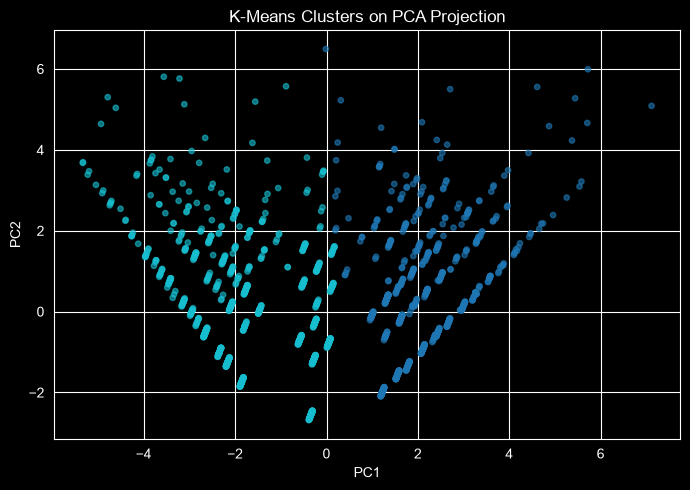

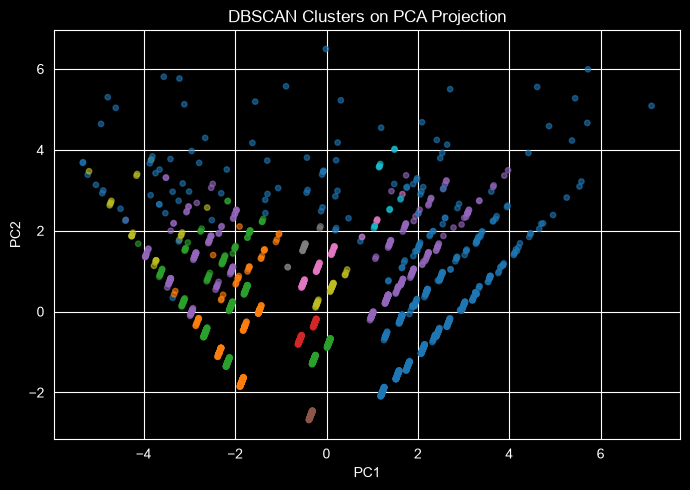

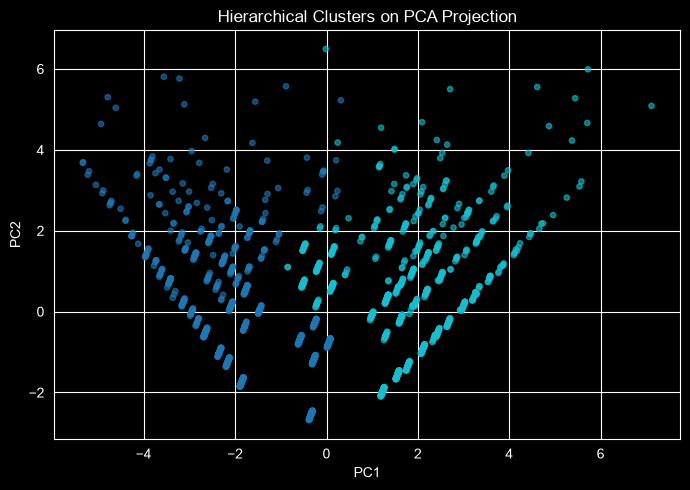

,matchday,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,home_points,away_points
cluster,,,,,,,,,
0,16.92,2.52,0.67,1.14,0.32,1.85,3.19,2.97,0.02
1,17.66,0.78,1.86,0.36,0.80,-1.08,2.64,0.41,2.18


In [31]:
# K-Means: choose k from 2..6 using silhouette score.
k_results = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    k_results.append((k, silhouette_score(X_scaled, labels)))

k_table = pd.DataFrame(k_results, columns=["k", "silhouette"])
display(k_table.round(3))
best_k = int(k_table.loc[k_table["silhouette"].idxmax(), "k"])
print("Selected k:", best_k)

start = time.perf_counter()
kmeans_labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_scaled)
kmeans_time = time.perf_counter() - start

# DBSCAN: eps is selected from the 90th percentile of 5-nearest-neighbor distances.
MIN_SAMPLES = 5
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
EPS = float(np.quantile(distances[:, -1], 0.90))
start = time.perf_counter()
dbscan_labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(X_scaled)
dbscan_time = time.perf_counter() - start

start = time.perf_counter()
hier_labels = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit_predict(X_scaled)
hier_time = time.perf_counter() - start

print("DBSCAN eps:", round(EPS, 3), "min_samples:", MIN_SAMPLES)
print("DBSCAN clusters:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
      "noise points:", int((dbscan_labels == -1).sum()))

def cluster_metrics(name, labels, runtime):
    valid = labels != -1
    unique = np.unique(labels[valid])
    sil = silhouette_score(X_scaled[valid], labels[valid]) if len(unique) > 1 else np.nan
    global_var = np.var(X_scaled, axis=0).mean()
    within_vars = []
    for c in unique:
        rows = X_scaled[labels == c]
        if len(rows) > 1:
            within_vars.append(np.var(rows, axis=0).mean())
    avg_within = np.mean(within_vars) if within_vars else np.nan
    return [name, len(unique), sil, avg_within, global_var, avg_within/global_var, runtime]

cluster_eval = pd.DataFrame([
    cluster_metrics("K-Means", kmeans_labels, kmeans_time),
    cluster_metrics("DBSCAN", dbscan_labels, dbscan_time),
    cluster_metrics("Hierarchical", hier_labels, hier_time)
], columns=["method", "clusters", "silhouette", "avg_within_variance", "global_variance", "variance_ratio", "runtime_sec"])
display(cluster_eval.round(3))

for name, labels in [("K-Means", kmeans_labels), ("DBSCAN", dbscan_labels), ("Hierarchical", hier_labels)]:
    plt.figure(figsize=(7, 5))
    plt.scatter(pca_scores[:, 0], pca_scores[:, 1], c=labels, cmap="tab10", alpha=0.6, s=15)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"{name} Clusters on PCA Projection")
    plt.tight_layout(); plt.show()

# Real-world cluster profiles for K-Means.
profile = X.assign(cluster=kmeans_labels).groupby("cluster").mean().round(2)
display(profile)

### 4 Clustering Analysis - Interpretation
**K-Means** selected **k=2** because it had the best tested silhouette score (**0.321**). Its two groups mainly separate matches with strong home-team outcomes from the remaining/away-favored outcomes; the cluster profile supports this interpretation. **Hierarchical clustering** also produced two groups with a similar silhouette (**0.305**), while **DBSCAN** produced **15 clusters plus 103 noise points** and a lower silhouette (**0.143**).

K-Means assumes compact centroid-based groups, DBSCAN searches for dense connected regions, and Hierarchical clustering merges observations according to distance. Their disagreement is therefore expected. The relatively modest silhouette scores indicate that the data do not contain very sharply separated natural clusters. The within-cluster/global-variance ratio is reported as requested; lower values mean more compact groups, but silhouette is more informative here because it also considers separation between clusters.

### Clustering on the Feature Space

The assignment also requires clustering the **features**, not only the matches. The standardized data matrix is transposed so each original variable becomes one object described by its values across matches.

In [32]:
feature_matrix = X_scaled.T
feature_labels = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(feature_matrix)
feature_clusters = pd.DataFrame({"feature": numeric_features, "feature_cluster": feature_labels})
display(feature_clusters.sort_values("feature_cluster"))

,feature,feature_cluster
1,fulltime_home,0
3,halftime_home,0
5,goal_difference,0
6,total_goals,0
7,home_points,0
2,fulltime_away,1
4,halftime_away,1
8,away_points,1
0,matchday,2


### Feature-Space Clustering - Interpretation
The feature clustering produced a clear and interpretable structure: home-side variables (`fulltime_home`, `halftime_home`, `goal_difference`, `home_points`) group with `total_goals`; away-side variables (`fulltime_away`, `halftime_away`, `away_points`) form another group; and `matchday` is isolated in its own group. This agrees with the correlation and PCA results and reveals the dataset's redundancy. It also shows that `matchday` describes a different dimension of the match than the score/result variables.

## 5 Multi-Dimensional Anomaly Detection (25%)

This is the main part of the assignment. The same standardized numerical feature set is used for all three required methods.

### 5.1 Z-Score Method

A classical Z-score measures how many standard deviations a value is from its feature mean. Here, a row is flagged when at least one feature has `|z| > 3`. This is a feature-wise rule combined into a row-level anomaly decision.

Z-score anomalies: 94


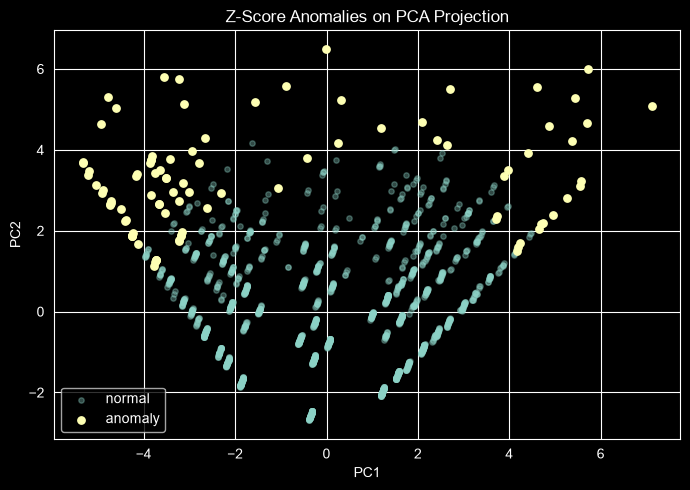

In [33]:
Z_THRESHOLD = 3.0
z_values = np.abs(X_scaled)
z_flags = (z_values > Z_THRESHOLD).any(axis=1)
print("Z-score anomalies:", int(z_flags.sum()))

plt.figure(figsize=(7, 5))
plt.scatter(pca_scores[~z_flags, 0], pca_scores[~z_flags, 1], alpha=0.35, s=15, label="normal")
plt.scatter(pca_scores[z_flags, 0], pca_scores[z_flags, 1], s=28, label="anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Z-Score Anomalies on PCA Projection")
plt.legend(); plt.tight_layout(); plt.show()

### 5.1 Z-Score - Interpretation
The method is simple and interpretable, but it relies on mean and standard deviation and is most natural under approximately Gaussian feature distributions. The EDA showed that football score variables are discrete and often skewed, so the Gaussian assumption is weak here. In higher dimensions, testing many features also increases the chance that a row is extreme on at least one coordinate. It can therefore flag legitimate rare football results as anomalies.

### 5.2 Isolation Forest

Isolation Forest repeatedly makes random splits. Observations that can be isolated in fewer splits receive more anomalous scores. `contamination=0.05` is used to request an anomaly fraction of approximately 5%; this is a modeling assumption, not a known true anomaly rate.

Isolation Forest anomalies: 97
Score interpretation: larger value here = more anomalous


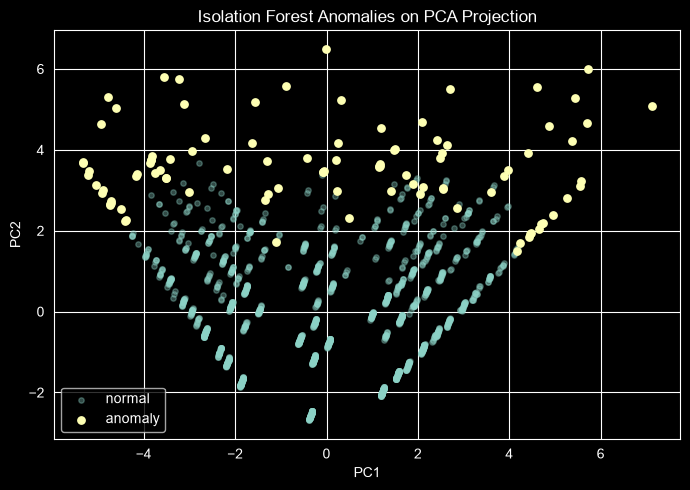

In [34]:
CONTAMINATION = 0.05
start = time.perf_counter()
iforest = IsolationForest(contamination=CONTAMINATION, random_state=42)
iforest_pred = iforest.fit_predict(X_scaled)
iforest_time = time.perf_counter() - start
iforest_flags = iforest_pred == -1
# sklearn decision_function: lower values are more abnormal, so negate it for an anomaly score.
iforest_score = -iforest.decision_function(X_scaled)
print("Isolation Forest anomalies:", int(iforest_flags.sum()))
print("Score interpretation: larger value here = more anomalous")

plt.figure(figsize=(7, 5))
plt.scatter(pca_scores[~iforest_flags, 0], pca_scores[~iforest_flags, 1], alpha=0.35, s=15, label="normal")
plt.scatter(pca_scores[iforest_flags, 0], pca_scores[iforest_flags, 1], s=28, label="anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Isolation Forest Anomalies on PCA Projection")
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Isolation Forest - Interpretation
Random partitioning makes unusual combinations of values easier to isolate than common observations. Unlike Z-score, Isolation Forest does not require Gaussian variables and can model multivariate abnormality. Its result still depends on the contamination setting and random partitions. It scales well to larger datasets, but the reason for a specific flag is less immediately interpretable than a single extreme Z-score.

### 5.3 Local Outlier Factor (LOF)

LOF compares the local density around each observation with the density around its neighbors. An observation in a much sparser local region receives a stronger outlier score. `n_neighbors=20` is used as a moderate local neighborhood for 1,941 observations.

LOF anomalies: 97
Score interpretation: larger value = more locally anomalous


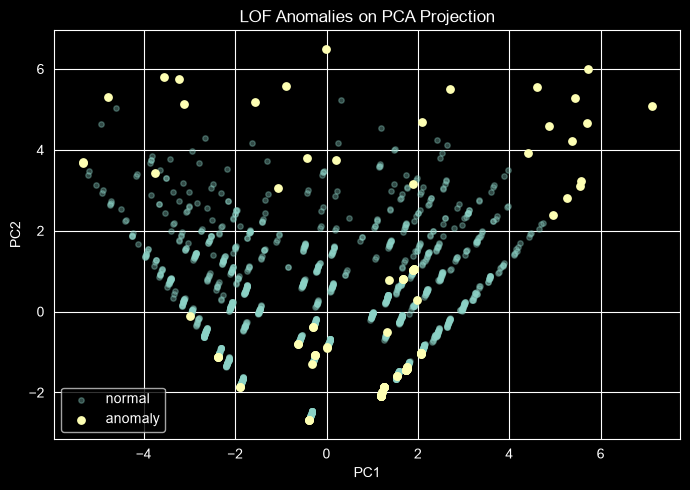

In [35]:
LOF_K = 20
start = time.perf_counter()
lof = LocalOutlierFactor(n_neighbors=LOF_K, contamination=CONTAMINATION)
lof_pred = lof.fit_predict(X_scaled)
lof_time = time.perf_counter() - start
lof_flags = lof_pred == -1
lof_score = -lof.negative_outlier_factor_
print("LOF anomalies:", int(lof_flags.sum()))
print("Score interpretation: larger value = more locally anomalous")

plt.figure(figsize=(7, 5))
plt.scatter(pca_scores[~lof_flags, 0], pca_scores[~lof_flags, 1], alpha=0.35, s=15, label="normal")
plt.scatter(pca_scores[lof_flags, 0], pca_scores[lof_flags, 1], s=28, label="anomaly")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("LOF Anomalies on PCA Projection")
plt.legend(); plt.tight_layout(); plt.show()

### 5.3 LOF - Interpretation
LOF is useful for **local anomalies**: a match can be unusual relative to nearby matches even if it is not globally extreme. The main sensitivity is the neighborhood size `k`; too small a k can react to noise, while too large a k can hide local structure. This differs from Z-score's global feature thresholds and Isolation Forest's random global partitioning.

## 6 Comparison Section

### Assignment requirements addressed
Compare agreement and method-specific anomalies, scaling and dimensionality sensitivity, runtime/scalability, robustness to noise, interpretability, and false positives/false negatives in the real-world context.

In [36]:
method_flags = pd.DataFrame({
    "Z-score": z_flags,
    "Isolation Forest": iforest_flags,
    "LOF": lof_flags
})
method_flags["methods_agreeing"] = method_flags.sum(axis=1)

agreement_table = pd.DataFrame({
    "anomalies": method_flags[["Z-score", "Isolation Forest", "LOF"]].sum(),
})
display(agreement_table)
print("Flagged by all three methods:", int((method_flags["methods_agreeing"] == 3).sum()))
print("Flagged by exactly one method:", int((method_flags["methods_agreeing"] == 1).sum()))

runtime_table = pd.DataFrame({
    "method": ["Isolation Forest", "LOF"],
    "runtime_sec": [iforest_time, lof_time]
})
display(runtime_table.round(4))

anomaly_examples = football.loc[method_flags["methods_agreeing"] >= 2,
    ["date_utc", "competition_name", "home_team", "away_team", "fulltime_home", "fulltime_away", "total_goals"]].copy()
anomaly_examples["methods_agreeing"] = method_flags.loc[method_flags["methods_agreeing"] >= 2, "methods_agreeing"].values
display(anomaly_examples.sort_values(["methods_agreeing", "total_goals"], ascending=False).head(15))

,anomalies
Z-score,94
Isolation Forest,97
LOF,97


Flagged by all three methods: 26
Flagged by exactly one method: 128


,method,runtime_sec
0,Isolation Forest,0.0656
1,LOF,0.0109


,date_utc,competition_name,home_team,away_team,fulltime_home,fulltime_away,total_goals,methods_agreeing
1755,2024-09-17 19:00:00+00:00,UEFA Champions League,FC Bayern München,GNK Dinamo Zagreb,9,2,11,3
169,2024-12-22 16:30:00+00:00,Premier League,Tottenham Hotspur FC,Liverpool FC,3,6,9,3
1214,2024-11-02 14:30:00+00:00,Bundesliga,Eintracht Frankfurt,VfL Bochum 1848,7,2,9,3
1909,2025-01-21 20:00:00+00:00,UEFA Champions League,Sport Lisboa e Benfica,FC Barcelona,4,5,9,3
18,2024-08-25 13:00:00+00:00,Premier League,Wolverhampton Wanderers FC,Chelsea FC,2,6,8,3
62,2024-10-05 14:00:00+00:00,Premier League,Brentford FC,Wolverhampton Wanderers FC,5,3,8,3
588,2025-01-26 20:00:00+00:00,La Liga,FC Barcelona,Valencia CF,7,1,8,3
625,2025-02-23 13:00:00+00:00,La Liga,Athletic Club,Real Valladolid CF,7,1,8,3
1406,2025-04-19 16:30:00+00:00,Bundesliga,1. FC Union Berlin,VfB Stuttgart,4,4,8,3
1482,2024-09-20 18:45:00+00:00,Ligue 1,OGC Nice,AS Saint-Étienne,8,0,8,3


### 6 Comparison - Interpretation
Z-score flagged **94** matches, Isolation Forest **97**, and LOF **97**. Only **25 matches** were flagged by all three methods, while **129** were flagged by exactly one method. This limited agreement is important: each method defines “unusual” differently. Z-score reacts to extreme individual features, Isolation Forest to easily isolated multivariate combinations, and LOF to low local density.

All methods are applied to standardized features so that variables with different numerical scales do not dominate. LOF is especially sensitive to dimensionality because neighborhood distances become less informative as dimensions increase. Isolation Forest handles multivariate patterns without a Gaussian assumption, while Z-score is easiest to explain but least compatible with the skewed score distributions.

There is **no ground-truth anomaly label**, so actual false-positive and false-negative rates cannot be calculated. A false positive would label a legitimate but rare football match as abnormal; a false negative would miss a genuinely erroneous or exceptional record.

## 7 Critical Analysis and Reflection (10%)

### Answer
Anomaly detection is ill-defined because there is no objective boundary between rare and abnormal observations. In this dataset, a very high-scoring match may be statistically unusual but completely legitimate.

The **curse of dimensionality** makes distances less discriminative as more features are added, which can weaken methods such as LOF and clustering. This dataset partly avoids very high dimensionality by using nine meaningful numerical variables, but several are redundant.

The distinction between **noise and a genuine anomaly** must be made using context. A match with an unusually large goal total can be a valid sporting event rather than a recording error. Z-score is particularly vulnerable to the non-Gaussian, discrete distributions seen in football scores, so it can over-flag legitimate tail observations or miss unusual multivariate combinations.

PCA visualizations can also mislead: 2D or 3D projections discard part of the variance. Two observations that appear close after projection may be separated in omitted dimensions, and apparent cluster separation can be stronger or weaker than in the original space.

### Ethical Considerations
False alarms can make anomaly systems ineffective when users stop trusting repeated warnings. In surveillance, anomaly detection may improve threat detection but creates privacy, bias, and fairness risks. In medicine, a false alarm can cause unnecessary testing and anxiety, while a missed anomaly can delay treatment. In cybersecurity, missing a real attack can be costly, while repeatedly flagging legitimate activity wastes analyst time. More generally, labeling people or behavior as “abnormal” requires caution because biased data or model assumptions can create unfair consequences.

## 8 Final Visualization Dashboard (Optional Bonus +5%)

The optional bonus section combines the main visual results in one notebook section: PCA projection, cluster visualization, interactive anomaly exploration, pairplots, and a correlation heatmap. The purpose is to make the structure of the data and the differences between methods easier to inspect.


### 8.1 PCA and Cluster Visualization
The first panel repeats the 2D PCA representation and the K-Means result in a compact form. This makes it easy to compare the overall geometry of the matches with the cluster assignment.


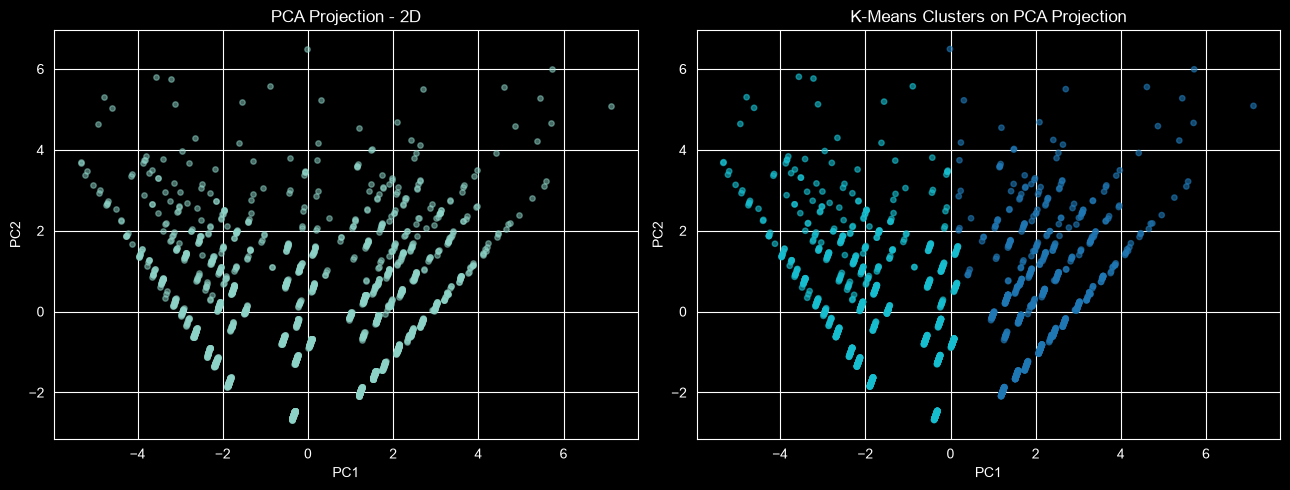

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=0.5, s=15)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA Projection - 2D")

axes[1].scatter(pca_scores[:, 0], pca_scores[:, 1], c=kmeans_labels, cmap="tab10", alpha=0.6, s=15)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("K-Means Clusters on PCA Projection")

plt.tight_layout()
plt.show()


**Interpretation:** The PCA projection shows a mostly continuous structure rather than clearly separated natural groups. K-Means still divides the observations into two clusters, mainly along PC1, but the moderate silhouette score indicates that the separation is not strong.


### 8.2 Interactive Anomaly Exploration
The interactive Plotly graph allows each match to be inspected by hovering over a point. The colour represents how many anomaly-detection methods identified that match as anomalous.


In [38]:
import plotly.express as px
import plotly.io as pio

# Use the native Colab renderer when the notebook is opened in Google Colab.
pio.renderers.default = "colab"

interactive_df = football[[
    "date_utc", "competition_name", "home_team", "away_team",
    "fulltime_home", "fulltime_away", "total_goals"
]].copy()
interactive_df["PC1"] = pca_scores[:, 0]
interactive_df["PC2"] = pca_scores[:, 1]
interactive_df["methods_agreeing"] = method_flags["methods_agreeing"].values
interactive_df["anomaly_group"] = interactive_df["methods_agreeing"].astype(str) + " methods"

fig = px.scatter(
    interactive_df,
    x="PC1",
    y="PC2",
    color="anomaly_group",
    hover_data=[
        "date_utc", "competition_name", "home_team", "away_team",
        "fulltime_home", "fulltime_away", "total_goals", "methods_agreeing"
    ],
    title="Interactive Anomaly Exploration on PCA Projection"
)
fig.show()


**Interpretation:** Points identified by several methods deserve more attention because different anomaly definitions agree on them. A point identified by only one method is more method-specific and should be interpreted with greater caution. Hovering over a point connects the statistical result to the actual football match.


### 8.3 Pairplots
A scatter-matrix is used for four representative numerical features. It shows pairwise relationships and the distribution of each feature without adding a separate graph for every possible pair.


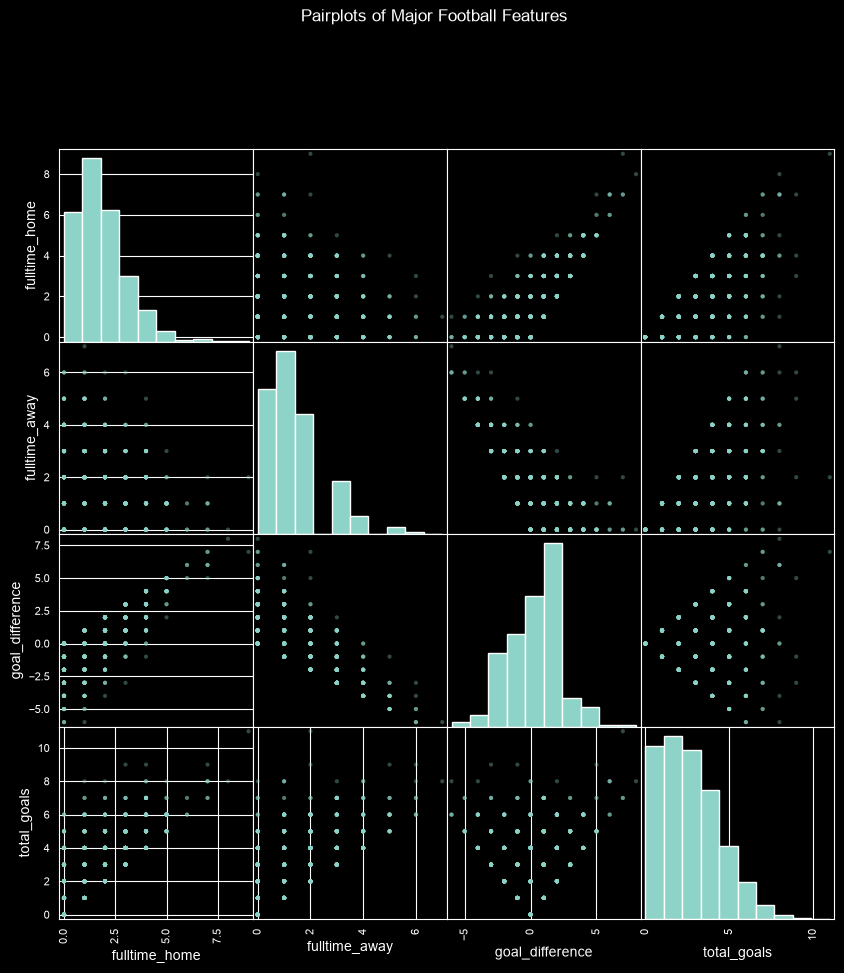

In [39]:
pair_features = ["fulltime_home", "fulltime_away", "goal_difference", "total_goals"]

pd.plotting.scatter_matrix(
    X[pair_features],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.35
)
plt.suptitle("Pairplots of Major Football Features", y=1.02)
plt.show()


**Interpretation:** The pairplots make the relationships between score-related variables visible. Strong geometric patterns are expected because total goals and goal difference are mathematically related to the home and away scores. This confirms that some of the original features are redundant.


### 8.4 Correlation Heatmap
The heatmap summarizes linear relationships between all numerical features used in the unsupervised analysis.


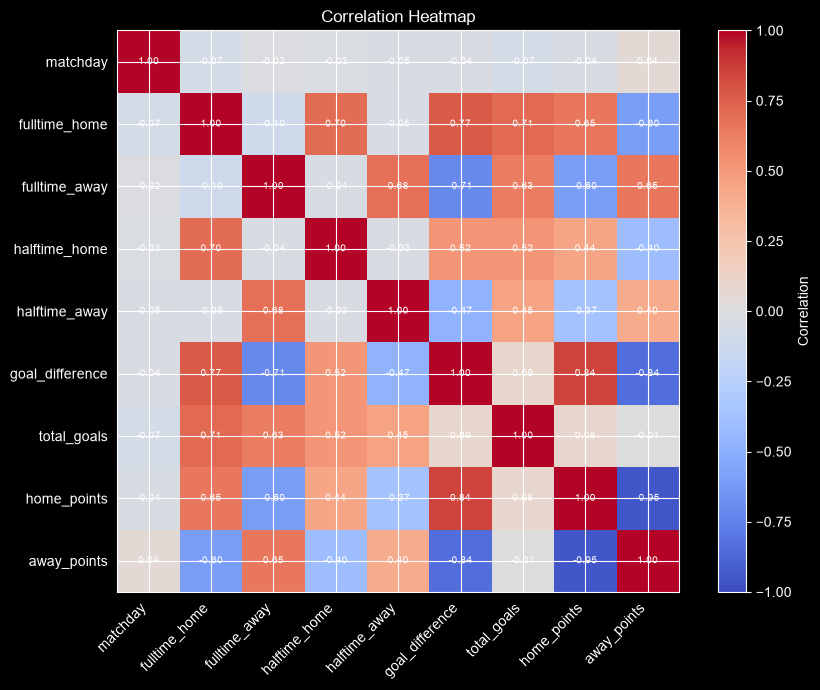

In [40]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
n = len(corr.columns)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Interpretation:** Strong correlations appear among score, goal-difference, and points variables. This supports the PCA result: several original variables contain overlapping information, so a smaller number of principal components can retain most of the variance.


## 9 Submission Requirements

The notebook contains the required methodology, mathematical intuition, visualizations, interpretations, assumptions, limitations, parameter choices, and reproducible code. Conclusions are written directly inside the notebook after the relevant analyses.